# Comparação entre simulação OpenDSS Puro e Co-simulação Mosaik

O sistema utilizado em estudo consiste no sistema de 123 barras do IEEE.

Entre as condiçõos o qual simulações foram performadas, destaca-se

- Controle dos reguladores de tensão desabilitados
- Modo de controle = Time
- Simulação de 24 horas ao passo de 5 minutos

O comparativo analisa os resultados do comportamento deste sistema na com e sem presenção de um sistema fotovoltaico, a saber o elemento PVSystem utilizado é

```bash
New PVSystem.PV phases=3 Bus1=680 kV=4.16 kVA=1000 irrad=0.8 Pmpp=1000
~ temperature=25 PF=1 EffCurve=MyEff P-TCurve=MyPvsT
~ Daily=my_shape2_pv TDaily=MyTemp
~ Vminpu=0.001
~ Model=1
```

Por fim, utiliza-se uma métrica de rmse e mae para analisar a diferença entre as grandezas obtidas por opendss puro e co-simulação mosaik

## Dominio do OpenDSS puro

In [1]:
# Standard library
import os
from pathlib import Path
import math
from collections import defaultdict
import re
import random
from tqdm import tqdm
import datetime as dt

# Third-party
import py_dss_interface
from simulators.api_opendss import OpenDSS
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

PosixPath('/mnt/c/Users/pvict/documents/UFC/GREI/GREI_Projeto_OpenTES/tsre/tsre-der-opentes/src')

In [3]:
dss = py_dss_interface.DSS()


In [4]:
DSS_FILE = BASE_DIR / 'data' / '13Bus' / 'run_ieee13_cosim_pv_5min.dss'

dss.text('Clear')
dss.text(f"Compile '{DSS_FILE}'")
dss.text("Solve")

dss.circuit.set_active_bus('650')
kv_650 = dss.bus.kv_base * 1000

dss.monitors.name = 'feeder_output_vi'

l650632_va_mag_pv = [v/kv_650 for v in dss.monitors.channel(1)]
l650632_vb_mag_pv = [v/kv_650 for v in dss.monitors.channel(3)]
l650632_vc_mag_pv = [v/kv_650 for v in dss.monitors.channel(5)]

dss.monitors.name = 'feeder_output_pq'

l650632_pa_pv = dss.monitors.channel(1)
l650632_qa_pv = dss.monitors.channel(2)
l650632_pb_pv = dss.monitors.channel(3)
l650632_qb_pv = dss.monitors.channel(4)
l650632_pc_pv = dss.monitors.channel(5)
l650632_qc_pv = dss.monitors.channel(6)

dss.circuit.set_active_bus('680')
kv_680 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line671680_vi'
bus680_va_pv = [v/kv_680 for v in dss.monitors.channel(1)]
bus680_vb_pv = [v/kv_680 for v in dss.monitors.channel(3)]
bus680_vc_pv = [v/kv_680 for v in dss.monitors.channel(5)]

dss.circuit.set_active_bus('611')
kv_611 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line684611_vi'
bus611_va_pv = [v*0 for v in dss.monitors.channel(1)]
bus611_vb_pv = [v*0 for v in dss.monitors.channel(1)]
bus611_vc_pv = [v/kv_611 for v in dss.monitors.channel(1)]

# # Barramento 114
# dss.circuit.set_active_bus('114')
# kv_114 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line113_vi'
# bus114_va_pv = [v/kv_114 for v in dss.monitors.channel(1)]
# bus114_vb_pv = [v*0 for v in dss.monitors.channel(1)]
# bus114_vc_pv = [v*0 for v in dss.monitors.channel(1)]

# # Barramento 92
# dss.circuit.set_active_bus('92')
# kv_92 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line91_vi'
# bus92_va_pv = [v*0 for v in dss.monitors.channel(1)]
# bus92_vb_pv = [v*0 for v in dss.monitors.channel(1)]
# bus92_vc_pv = [v/kv_92 for v in dss.monitors.channel(1)]

# # Barramento 20
# dss.circuit.set_active_bus('20')
# kv_20 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line20_vi'
# bus20_va_pv = [v/kv_20 for v in dss.monitors.channel(1)]
# bus20_vb_pv = [v/kv_20 for v in dss.monitors.channel(3)]
# bus20_vc_pv = [v/kv_20 for v in dss.monitors.channel(5)]

# # Barramento 52
# dss.circuit.set_active_bus('52')
# kv_52 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line52_vi'
# bus52_va_pv = [v/kv_52 for v in dss.monitors.channel(1)]
# bus52_vb_pv = [v/kv_52 for v in dss.monitors.channel(3)]
# bus52_vc_pv = [v/kv_52 for v in dss.monitors.channel(5)]

# # Barramento 151
# dss.circuit.set_active_bus('151')
# kv_151 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line51_vi'
# bus151_va_pv = [v/kv_151 for v in dss.monitors.channel(1)]
# bus151_vb_pv = [v/kv_151 for v in dss.monitors.channel(3)]
# bus151_vc_pv = [v/kv_151 for v in dss.monitors.channel(5)]

# # Barramento 85
# dss.circuit.set_active_bus('85')
# kv_85 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line85_vi'
# bus85_va_pv = [v/kv_85 for v in dss.monitors.channel(1)]
# bus85_vb_pv = [v/kv_85 for v in dss.monitors.channel(3)]
# bus85_vc_pv = [v/kv_85 for v in dss.monitors.channel(5)]

# dss.monitors.name = 'pv_output'
# pa_pv = [-1*p for p in dss.monitors.channel(1)]
# qa_pv = dss.monitors.channel(2)
# pb_pv = [-1*p for p in dss.monitors.channel(3)]
# qb_pv = dss.monitors.channel(4)
# pc_pv = [-1*p for p in dss.monitors.channel(5)]
# qc_pv = dss.monitors.channel(6)


Waiting...
Actor 1: Job done
>>Waiting...
Actor 1: Job done
>>

## Co-simulação Mosaik

In [7]:
df_cosim_pv = pd.read_csv(BASE_DIR / 'output' / 'result_run_ieee13_cosim_smart_pv_5min.csv')

l650632_va_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-650-V1_pu']
l650632_vb_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-650-V2_pu']
l650632_vc_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-650-V3_pu']

# l650632_pa_pv_cosim = df_cosim_pv['DSS-0.Line-650632-P1_w']
# l650632_qa_pv_cosim = df_cosim_pv['DSS-0.Line-650632-Q1_var']
# l650632_pb_pv_cosim = df_cosim_pv['DSS-0.Line-650632-P2_w']
# l650632_qb_pv_cosim = df_cosim_pv['DSS-0.Line-650632-Q2_var']
# l650632_pc_pv_cosim = df_cosim_pv['DSS-0.Line-650632-P3_w']
# l650632_qc_pv_cosim = df_cosim_pv['DSS-0.Line-650632-Q3_var']

bus680_va_pv_cosim = df_cosim_pv['DSS-0.Bus-680-V1_pu']
bus680_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-680-V2_pu']
bus680_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-680-V3_pu']

bus611_va_pv_cosim = df_cosim_pv['DSS-0.Bus-611-V1_pu']
bus611_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-611-V2_pu']
bus611_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-611-V3_pu']

# bus114_va_pv_cosim = df_cosim_pv['DSS-0.Bus-114-V1_pu']
# bus114_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-114-V2_pu']
# bus114_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-114-V3_pu']

# bus92_va_pv_cosim = df_cosim_pv['DSS-0.Bus-92-V1_pu']
# bus92_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-92-V2_pu']
# bus92_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-92-V3_pu']

# pa_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P1']
# qa_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-Q1']
# pb_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P2']
# qb_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-Q2']
# pc_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P3']
# qc_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-Q3']

temperature_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-temperature']
irradiance_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-irradiance']

pv_dc_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-P_dc']
inv_pac_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P_meas']

## Comparação OpenDSS puro e Co-simulação Mosaik

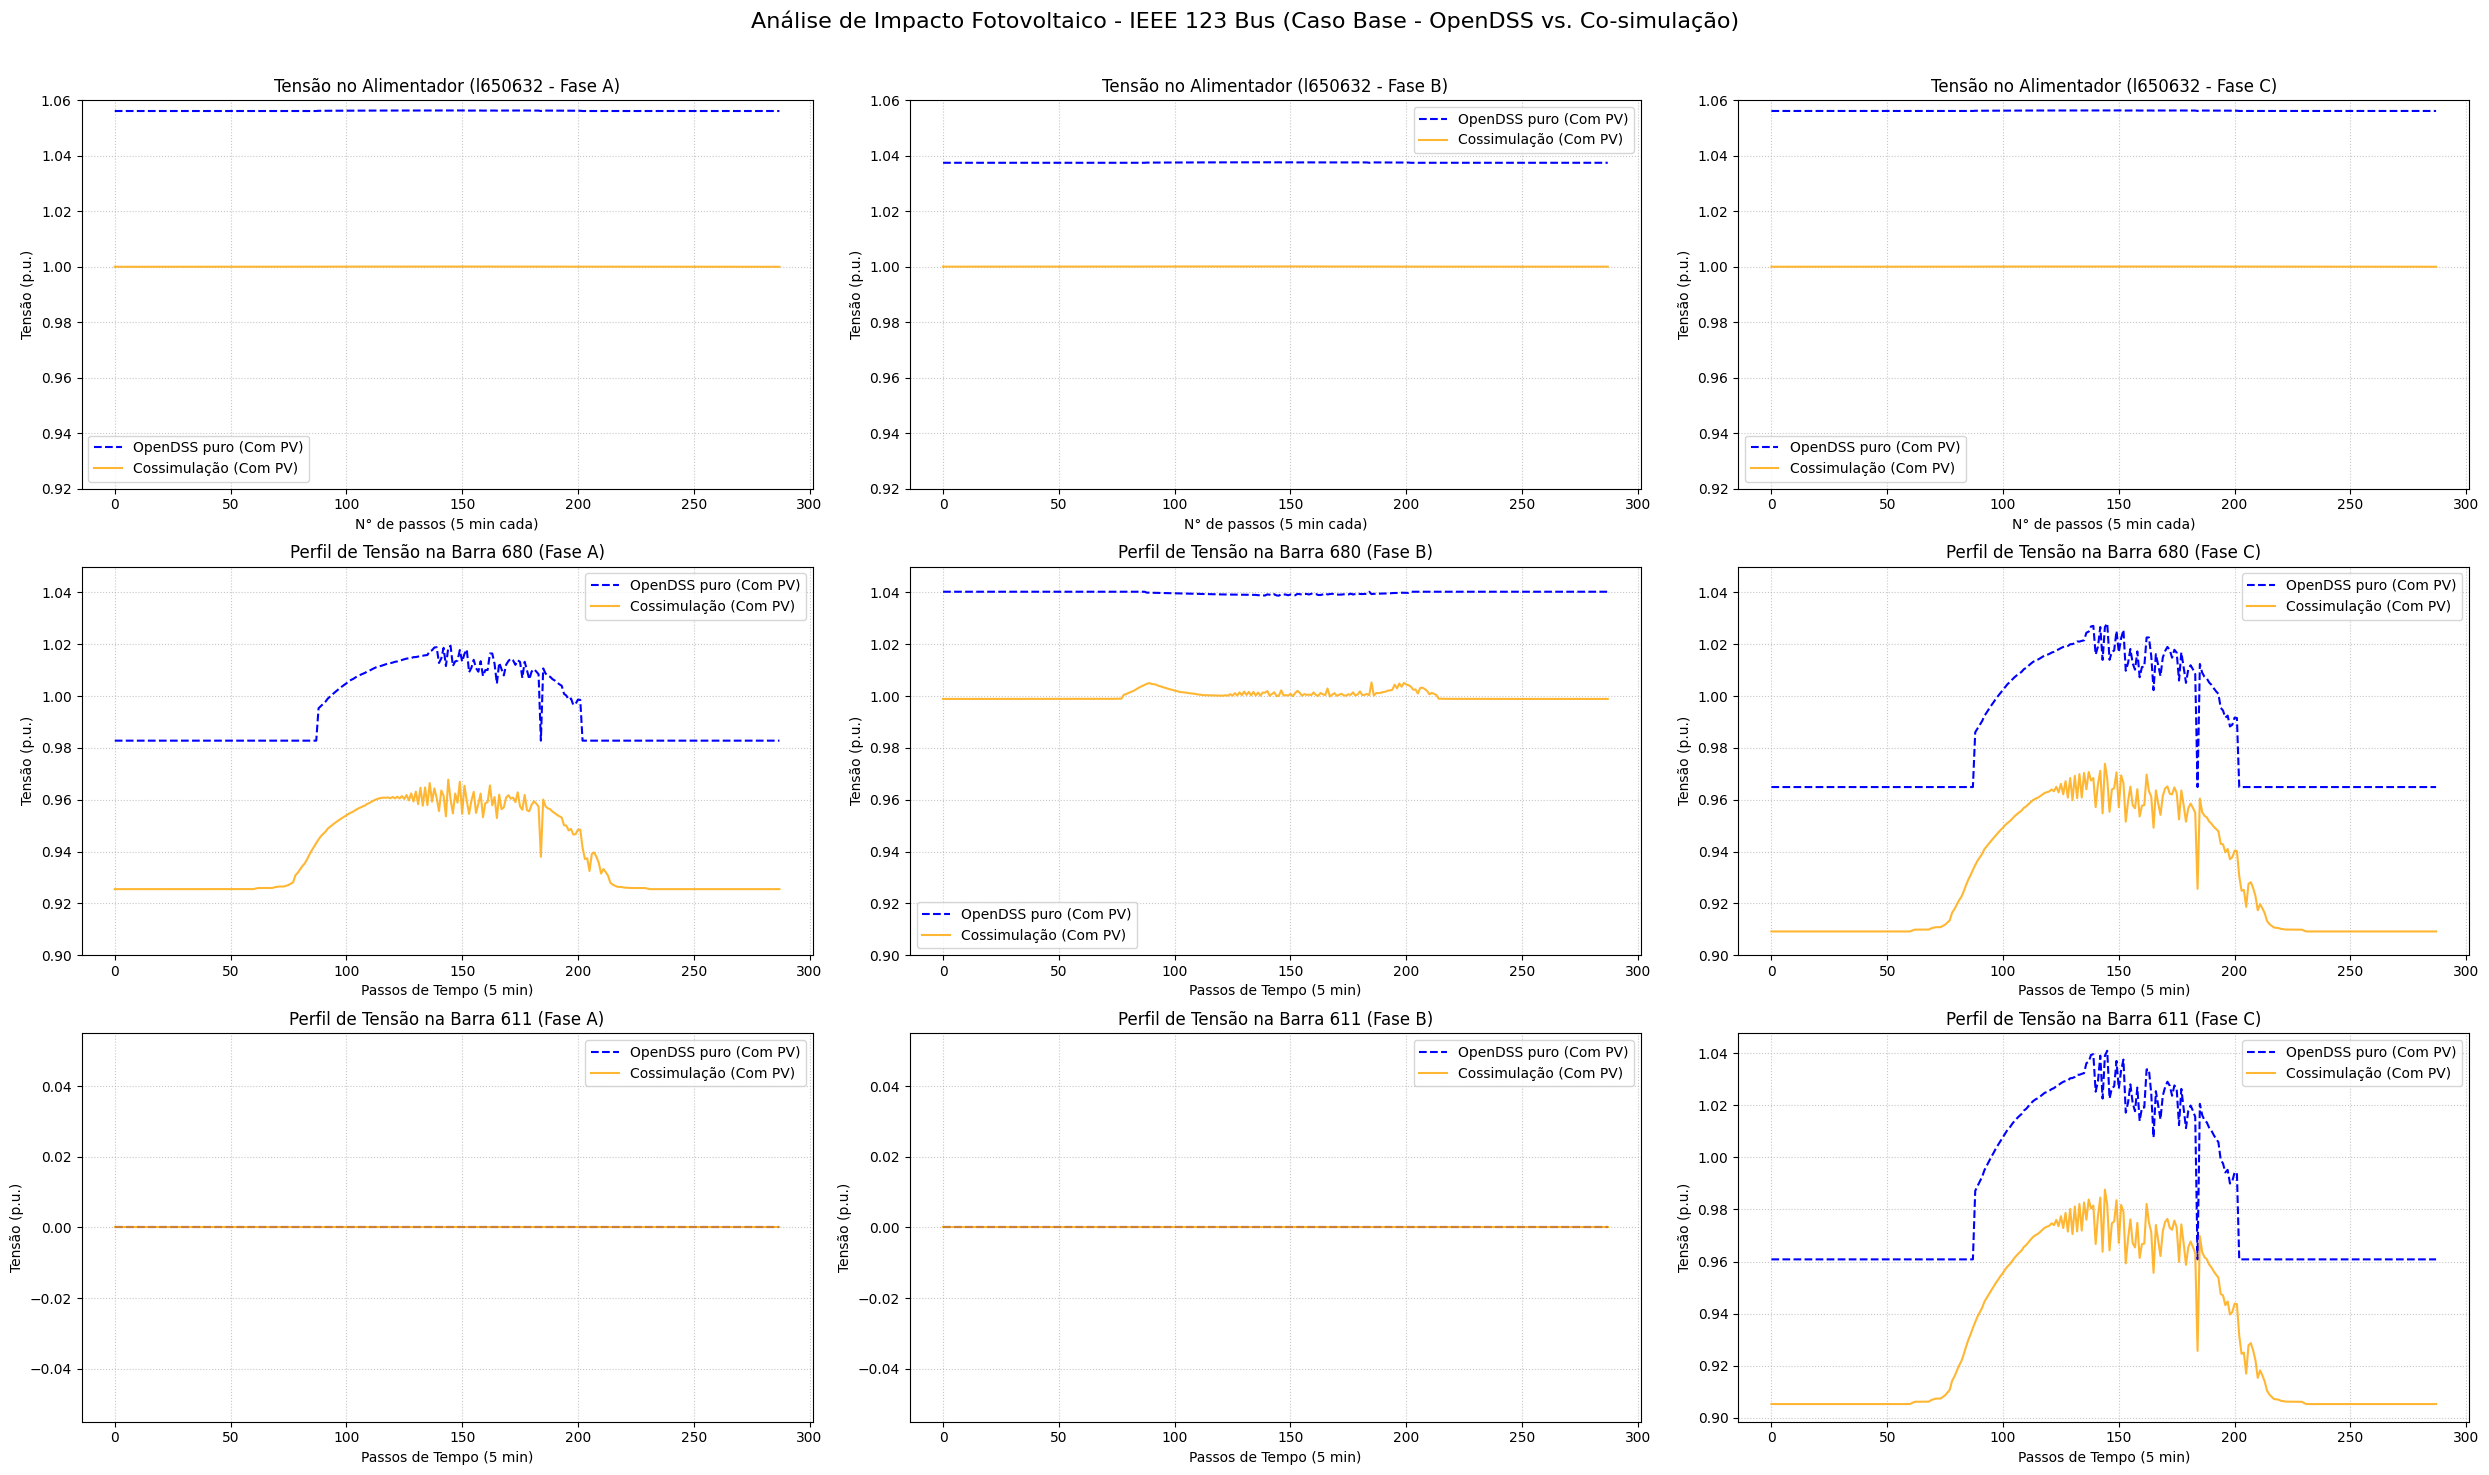

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Cria um eixo x baseado no número de pontos (passos de 5 minutos)
# Assumindo que todos os canais têm o mesmo tamanho
passos = range(len(l650632_va_mag_pv))

# Cria uma figura com uma grade 3x3 de subgráficos
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Análise de Impacto Fotovoltaico - IEEE 123 Bus (Caso Base - OpenDSS vs. Co-simulação)', fontsize=16)

# ==================== PRIMEIRA LINHA (índice 0) ====================
# Limites do eixo Y: 0.92 a 1.06
axs[0, 0].plot(passos, l650632_va_mag_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[0, 0].plot(passos, l650632_va_mag_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[0, 0].set_title('Tensão no Alimentador (l650632 - Fase A)')
axs[0, 0].set_ylabel('Tensão (p.u.)')
axs[0, 0].set_xlabel('N° de passos (5 min cada)')
axs[0, 0].grid(True, linestyle=':', alpha=0.7)
axs[0, 0].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 0].legend()
axs[0, 0].set_ylim(0.92, 1.06)  # <--- NOVO

axs[0, 1].plot(passos, l650632_vb_mag_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[0, 1].plot(passos, l650632_vb_mag_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[0, 1].set_title('Tensão no Alimentador (l650632 - Fase B)')
axs[0, 1].set_ylabel('Tensão (p.u.)')
axs[0, 1].set_xlabel('N° de passos (5 min cada)')
axs[0, 1].grid(True, linestyle=':', alpha=0.7)
axs[0, 1].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 1].legend()
axs[0, 1].set_ylim(0.92, 1.06)  # <--- NOVO

axs[0, 2].plot(passos, l650632_vc_mag_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[0, 2].plot(passos, l650632_vc_mag_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[0, 2].set_title('Tensão no Alimentador (l650632 - Fase C)')
axs[0, 2].set_ylabel('Tensão (p.u.)')
axs[0, 2].set_xlabel('N° de passos (5 min cada)')
axs[0, 2].grid(True, linestyle=':', alpha=0.7)
axs[0, 2].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 2].legend()
axs[0, 2].set_ylim(0.92, 1.06)  # <--- NOVO

# ==================== SEGUNDA LINHA (índice 1) ====================
# Limites do eixo Y: 0.90 a 1.05
axs[1, 0].plot(passos, bus680_va_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[1, 0].plot(passos, bus680_va_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[1, 0].set_title('Perfil de Tensão na Barra 680 (Fase A)')
axs[1, 0].set_xlabel('Passos de Tempo (5 min)')
axs[1, 0].set_ylabel('Tensão (p.u.)')
axs[1, 0].grid(True, linestyle=':', alpha=0.7)
axs[1, 0].legend()
axs[1, 0].set_ylim(0.90, 1.05)  # <--- NOVO

axs[1, 1].plot(passos, bus680_vb_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[1, 1].plot(passos, bus680_vb_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[1, 1].set_title('Perfil de Tensão na Barra 680 (Fase B)')
axs[1, 1].set_xlabel('Passos de Tempo (5 min)')
axs[1, 1].set_ylabel('Tensão (p.u.)')
axs[1, 1].grid(True, linestyle=':', alpha=0.7)
axs[1, 1].legend()
axs[1, 1].set_ylim(0.90, 1.05)  # <--- NOVO

axs[1, 2].plot(passos, bus680_vc_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[1, 2].plot(passos, bus680_vc_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[1, 2].set_title('Perfil de Tensão na Barra 680 (Fase C)')
axs[1, 2].set_xlabel('Passos de Tempo (5 min)')
axs[1, 2].set_ylabel('Tensão (p.u.)')
axs[1, 2].grid(True, linestyle=':', alpha=0.7)
axs[1, 2].legend()
axs[1, 2].set_ylim(0.90, 1.05)  # <--- NOVO

# ==================== TERCEIRA LINHA (índice 2) ====================
# Limites do eixo Y: -0.05 a 1.05
axs[2, 0].plot(passos, bus611_va_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[2, 0].plot(passos, bus611_va_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[2, 0].set_title('Perfil de Tensão na Barra 611 (Fase A)')
axs[2, 0].set_xlabel('Passos de Tempo (5 min)')
axs[2, 0].set_ylabel('Tensão (p.u.)')
axs[2, 0].grid(True, linestyle=':', alpha=0.7)
axs[2, 0].legend()
#axs[2, 0].set_ylim(-0.05, 1.05)  # <--- NOVO

axs[2, 1].plot(passos, bus611_vb_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[2, 1].plot(passos, bus611_vb_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[2, 1].set_title('Perfil de Tensão na Barra 611 (Fase B)')
axs[2, 1].set_xlabel('Passos de Tempo (5 min)')
axs[2, 1].set_ylabel('Tensão (p.u.)')
axs[2, 1].grid(True, linestyle=':', alpha=0.7)
axs[2, 1].legend()
#axs[2, 1].set_ylim(-0.05, 1.05)  # <--- NOVO

axs[2, 2].plot(passos, bus611_vc_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[2, 2].plot(passos, bus611_vc_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[2, 2].set_title('Perfil de Tensão na Barra 611 (Fase C)')
axs[2, 2].set_xlabel('Passos de Tempo (5 min)')
axs[2, 2].set_ylabel('Tensão (p.u.)')
axs[2, 2].grid(True, linestyle=':', alpha=0.7)
axs[2, 2].legend()
#axs[2, 2].set_ylim(-0.05, 1.05)  # <--- NOVO

# Ajusta o layout para evitar sobreposição de textos
plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Espaço para o título principal
plt.show()

In [ ]:
# ==============================================================================
# ALGORITMO DE CÁLCULO DE MÉTRICAS DE ERRO (PURO PYTHON)
# ==============================================================================

def calcular_rmse_mae(lista_referencia, lista_medicao):
    """
    Calcula o RMSE e o MAE entre duas listas de valores sem usar bibliotecas.
    lista_referencia: Valores do OpenDSS puro (Ground Truth).
    lista_medicao: Valores da Co-simulação no Mosaik.
    """
    # Garantir que as listas são do tipo list (convertendo de pandas Series se necessário)
    ref = list(lista_referencia)
    med = list(lista_medicao)
    
    # Alinhar tamanhos caso as simulações tenham diferença de 1 step no final
    tamanho = min(len(ref), len(med))
    if tamanho == 0:
        return None, None
        
    soma_erros_quadrados = 0.0
    soma_erros_absolutos = 0.0
    
    for i in range(tamanho):
        erro = ref[i] - med[i]
        soma_erros_quadrados += erro ** 2
        soma_erros_absolutos += abs(erro)
        
    mse = soma_erros_quadrados / tamanho
    rmse = mse ** 0.5  # Raiz quadrada sem usar math.sqrt
    mae = soma_erros_absolutos / tamanho
    
    return rmse, mae

# ==============================================================================
# MAPEAMENTO DAS CURVAS COMPARÁVEIS
# ==============================================================================

# Dicionário organizando o Nome da Grandeza, Curva OpenDSS e Curva Mosaik.
# Obs: Descartei variáveis internas do Mosaik que não foram extraídas do 
# OpenDSS puro (ex: temperature_cosim, pv_dc_cosim).

comparacoes = {
    # # --- CASO 1: SEM PV (IEEE 123 Original) ---
    # "Tensão Bus 149 (Fase A) [pu]": (650632_va_mag, 650632_va_mag_cosim),
    # "Tensão Bus 149 (Fase B) [pu]": (650632_vb_mag, 650632_vb_mag_cosim),
    # "Tensão Bus 149 (Fase C) [pu]": (650632_vc_mag, 650632_vc_mag_cosim),
    
    # "Tensão Bus 97 (Fase A) [pu] ": (bus680_va, bus680_va_cosim),
    # "Tensão Bus 97 (Fase B) [pu] ": (bus680_vb, bus680_vb_cosim),
    # "Tensão Bus 97 (Fase C) [pu] ": (bus680_vc, bus680_vc_cosim),
    
    # "Potência Ativa 650632 (Fase A) [kW]": (650632_pa, 650632_pa_cosim),
    # "Pot. Reativa 650632 (Fase A) [kvar]": (650632_qa, 650632_qa_cosim),
    # # Você pode adicionar as Fases B e C da linha 115 aqui se desejar...

    # --- CASO 2: COM PV INTEGRADO ---
    "PV_Tensão Bus 149 (Fase A) [pu]": (650632_va_mag_pv, 650632_va_mag_pv_cosim),
    "PV_Tensão Bus 149 (Fase B) [pu]": (650632_vb_mag_pv, 650632_vb_mag_pv_cosim),
    "PV_Tensão Bus 149 (Fase C) [pu]": (650632_vc_mag_pv, 650632_vc_mag_pv_cosim),
    # --- BUS 97 ---
    "PV_Tensão Bus 97 (Fase A) [pu] ": (bus680_va_pv, bus680_va_pv_cosim),
    "PV_Tensão Bus 97 (Fase B) [pu] ": (bus680_vb_pv, bus680_vb_pv_cosim),
    "PV_Tensão Bus 97 (Fase C) [pu] ": (bus680_vc_pv, bus680_vc_pv_cosim),

    # --- BUS 29 ---
    "PV_Tensão Bus 29 (Fase A) [pu] ": (bus611_va_pv, bus611_va_pv_cosim),
    "PV_Tensão Bus 29 (Fase B) [pu] ": (bus611_vb_pv, bus611_vb_pv_cosim),
    "PV_Tensão Bus 29 (Fase C) [pu] ": (bus611_vc_pv, bus611_vc_pv_cosim),

    # --- BUS 114 ---
    "PV_Tensão Bus 114 (Fase A) [pu]": (bus114_va_pv, bus114_va_pv_cosim),
    "PV_Tensão Bus 114 (Fase B) [pu]": (bus114_vb_pv, bus114_vb_pv_cosim),
    "PV_Tensão Bus 114 (Fase C) [pu]": (bus114_vc_pv, bus114_vc_pv_cosim),

    # --- BUS 92 ---
    "PV_Tensão Bus 92 (Fase A) [pu] ": (bus92_va_pv, bus92_va_pv_cosim),
    "PV_Tensão Bus 92 (Fase B) [pu] ": (bus92_vb_pv, bus92_vb_pv_cosim),
    "PV_Tensão Bus 92 (Fase C) [pu] ": (bus92_vc_pv, bus92_vc_pv_cosim),
    
    # "PV_Potência Ativa 650632 (Fase A) [kW]": (650632_pa_pv, 650632_pa_pv_cosim),
    
    # "PV_Geração Ativa Bus 97 (Fase A) [kW]  ": (pa_pv, pa_pv_cosim),
    # "PV_Geração Ativa Bus 97 (Fase B) [kW]  ": (pb_pv, pb_pv_cosim),
    # "PV_Geração Ativa Bus 97 (Fase C) [kW]  ": (pc_pv, pc_pv_cosim),
    
    # "PV_Geração Reativa Bus 97 (Fase A) [kvar]": (qa_pv, qa_pv_cosim),
    # "PV_Geração Reativa Bus 97 (Fase B) [kvar]": (qb_pv, qb_pv_cosim),
    # "PV_Geração Reativa Bus 97 (Fase C) [kvar]": (qc_pv, qc_pv_cosim),
}

# ==============================================================================
# EXECUÇÃO E RELATÓRIO
# ==============================================================================

print("="*80)
print(f"{'RELATÓRIO DE ERROS: OPENDSS PURO vs MOSAIK CO-SIMULATION':^80}")
print("="*80)
print(f"{'Grandeza Analisada':<40} | {'RMSE':<15} | {'MAE':<15}")
print("-" * 80)

for nome_grandeza, (curva_ref, curva_med) in comparacoes.items():
    rmse, mae = calcular_rmse_mae(curva_ref, curva_med)
    
    if rmse is not None:
        # Formatando para notação científica caso o erro seja muito pequeno
        # ou fixando em 6 casas decimais
        print(f"{nome_grandeza:<40} | {rmse:<15.6f} | {mae:<15.6f}")
    else:
        print(f"{nome_grandeza:<40} | {'ERRO DE DADOS':<15} | {'ERRO DE DADOS':<15}")

print("="*80)